In [1]:
# 0. 환경 설정 & 임포트
# ------------------------------------------------------------
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

try:
    import sionna.rt
except ImportError:
    os.system("pip install sionna-rt")
    import sionna.rt

from sionna.rt import (
    load_scene, PlanarArray, Transmitter, Receiver, Camera,
    PathSolver,
)
from sionna.rt.constants import InteractionType

no_preview = True  # True: scene.render()로 정적 이미지 생성 (headless 환경에서 안전)

print("Sionna version:", sionna.rt.__version__ if hasattr(sionna.rt, "__version__") else "unknown")


jitc_llvm_init(): LLVM API initialization failed ..


Sionna version: 1.2.0


'\n## 2. BS 1개, UE(car) 1개 배치\n\n- **BS**: 건물 옆, 지상에서 약 15m 높이에 고정 (거리의 한쪽 끝)\n- **UE**: 도로를 따라 이동하는 차량(car_2) 단말, 초기 위치는 BS 반대쪽 끝 부근\n'

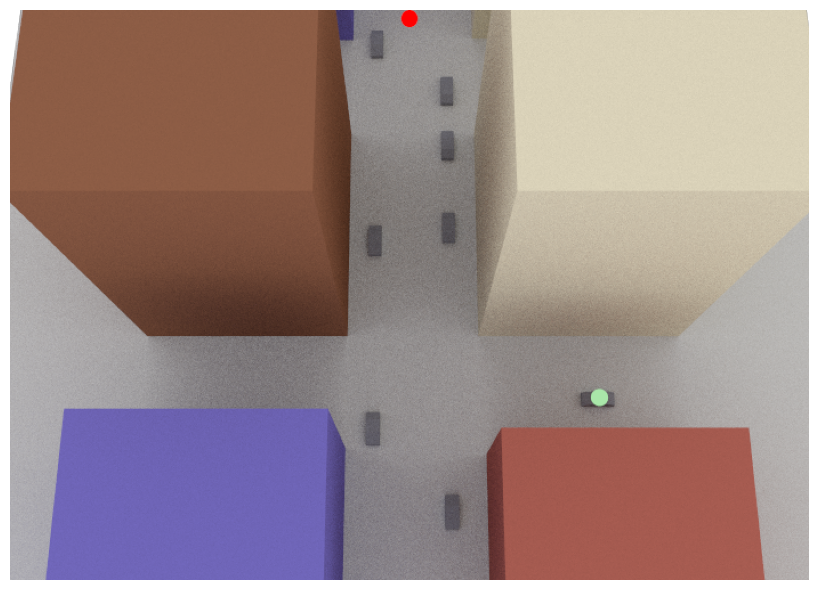

In [2]:
# ------------------------------------------------------------
# 1. Scene 로드
# ------------------------------------------------------------
scene = load_scene(sionna.rt.scene.simple_street_canyon_with_cars, merge_shapes=False)

# 안테나 배열 설정 (BS/UE 모두 단일 등방성 안테나 -> path 해석을 단순화)
# scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
# scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
num_bs_antennas = 32
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_bs_antennas,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             pattern="iso",
                             polarization="V")

# 가능하면 synthetic array를 사용하도록 설정 (Paths 텐서 shape을 단순하게 유지)
try:
    scene.synthetic_array = True
except Exception:
    pass

bs_pos = [-25.0, 0.0, 15.0]
tx = Transmitter(name="bs", position=bs_pos)
scene.add(tx)
# car_2 mesh는 그대로 두고 (장애물/반사체 역할)
car_2 = scene.get("car_2")
car_2.position += [0, 20, 0]
car_2.orientation = [np.pi/2, 0, 0]

# UE(안테나)는 별도 이름으로 생성, car_2 위치를 따라가도록 설정
# position에는 tensor가 아니라 plain list를 넣어주는 게 안전합니다
car_2_pos = car_2.position.numpy()[:, 0]          # [x, y, z]
ue_pos = car_2_pos + [0, 0, 1.0]                    # 차 지붕 위 1m에 안테나 마운트
ue_start_pos = ue_pos.copy()  # 시뮬레이션 시작 시점의 UE 위치

rx = Receiver(name="ue", position=ue_pos.tolist(), orientation=car_2.orientation)
scene.add(rx)


vel = -20
velocity=np.array([0, vel, 0])

cam = Camera(position=[50,0,130], look_at=[10,0,0])

if no_preview:
    scene.render(camera=cam, resolution=[700, 500]);
else:
    scene.preview()


"""
## 2. BS 1개, UE(car) 1개 배치

- **BS**: 건물 옆, 지상에서 약 15m 높이에 고정 (거리의 한쪽 끝)
- **UE**: 도로를 따라 이동하는 차량(car_2) 단말, 초기 위치는 BS 반대쪽 끝 부근
"""

In [3]:
"""## 3. Path 계산 및 시각화 (Dominant path 강조)

`PathSolver`로 BS-UE 사이의 propagation path를 계산합니다. 이후 아래 두 가지 방식으로 시각화합니다.

1. **Sionna 내장 렌더링** (`scene.render(paths=paths)`) — 3D 씬 위에 모든 path를 표시 (참고용)
2. **커스텀 matplotlib 3D 플롯** — `Paths.a`(경로 이득)로부터 dominant path를 찾아
   굵은 빨간 선으로, 나머지 path는 얇은 회색 선으로 표시

Dominant path는 "경로 이득의 크기(|a|) 제곱, 즉 수신 전력이 가장 큰 path"로 정의합니다.
"""

# ------------------------------------------------------------
# 3-1. Path 계산
# ------------------------------------------------------------
p_solver = PathSolver()

paths_t = p_solver(scene=scene,
                    max_depth=2,
                    los=True,
                    specular_reflection=True,
                    diffuse_reflection=False,
                    refraction=True,
                    diffraction=True,
                    synthetic_array=True,
                    seed=1)

# Sionna 내장 렌더링 (참고용) - 모든 경로가 함께 표시됨
if no_preview:
    scene.render(camera=cam, paths=paths, resolution=[700, 500]);
else:
    scene.preview(paths=paths)


NameError: name 'paths' is not defined

In [ ]:
# ------------------------------------------------------------
# 3-2. Paths 객체에서 dominant path 및 path geometry 추출
# ------------------------------------------------------------

def extract_path_data(paths):
    #Paths 객체에서 이후 시각화에 필요한 정보를 numpy array로 뽑아낸다.
    '''
    반환값:
        vertices      : (max_depth, num_paths, 3)  각 path의 상호작용 지점 좌표
        interactions  : (max_depth, num_paths)      상호작용 종류 (0 = 없음/LoS)
        power_db      : (num_paths,)                path별 수신 전력 (dB, 상대값)
        valid         : (num_paths,) bool           유효한(존재하는) path 여부
        dominant_idx  : int                         dominant path의 index
    '''
    verts = np.asarray(paths.vertices)          # (depth, rx, tx, num_paths, 3) 혹은 유사 shape
    inter = np.asarray(paths.interactions)      # (depth, rx, tx, num_paths)
    a = np.asarray(paths.a)                     # (rx, [rx_ant,] tx, [tx_ant,] num_paths[, time])
    if not np.iscomplexobj(a):
        # 일부 버전은 (real, imag)를 튜플/스택으로 반환 -> 마지막 축이 2인 경우 처리
        if a.shape[-1] == 2:
            a = a[..., 0] + 1j * a[..., 1]
        elif a.shape[0] == 2:
            a = a[0] + 1j * a[1]

    # rx/tx(=크기 1) 축 제거
    verts = np.squeeze(verts, axis=tuple(i for i in range(1, verts.ndim - 2) if verts.shape[i] == 1))
    inter = np.squeeze(inter, axis=tuple(i for i in range(1, inter.ndim - 1) if inter.shape[i] == 1))

    num_paths = inter.shape[-1]

    # a 는 rx/tx/antenna 조합이 여러 개 섞여 있을 수 있으므로 path 축 기준으로 power를 합산
    a_flat = a.reshape(-1, num_paths)
    power = np.sum(np.abs(a_flat) ** 2, axis=0)  # (num_paths,)

    valid = power > 0
    if not np.any(valid):
        raise RuntimeError("유효한 path가 없습니다 (BS-UE 사이에 도달 가능한 path가 없음).")

    power_db = 10 * np.log10(power + 1e-30)
    dominant_idx = int(np.argmax(power))

    return verts, inter, power_db, valid, dominant_idx


def path_polyline(tx_pos, rx_pos, verts, inter, p):
    #path index p에 대한 [TX -> 상호작용 지점들 -> RX] 좌표 리스트 반환
    pts = [np.asarray(tx_pos, dtype=float)]
    max_depth = verts.shape[0]
    for d in range(max_depth):
        if inter[d, p] != InteractionType.NONE:
            pts.append(verts[d, p])
    pts.append(np.asarray(rx_pos, dtype=float))
    return np.stack(pts, axis=0)


def path_type_str(inter, p):
    #path의 상호작용 타입을 사람이 읽기 쉬운 문자열로 변환
    depth = int(np.sum(inter[:, p] != InteractionType.NONE))
    if depth == 0:
        return "LoS"
    types = []
    for d in range(inter.shape[0]):
        t = int(inter[d, p])
        if t == InteractionType.NONE:
            continue
        elif t == InteractionType.SPECULAR:
            types.append("specular")
        elif t == InteractionType.DIFFUSE:
            types.append("diffuse")
        elif t == InteractionType.REFRACTION:
            types.append("refraction")
        elif t == InteractionType.DIFFRACTION:
            types.append("diffraction")
        else:
            types.append(f"type{t}")
    return f"{depth}st " + "+".join(types)


verts, inter, power_db, valid, dominant_idx = extract_path_data(paths)
num_paths = inter.shape[-1]

print(f"전체 path 후보 수: {num_paths}, 유효 path 수: {int(np.sum(valid))}")
for p in range(num_paths):
    if not valid[p]:
        continue
    marker = " <-- DOMINANT" if p == dominant_idx else ""
    print(f"  path {p:2d}: {path_type_str(inter, p):12s}  power = {power_db[p]:6.1f} dB{marker}")

In [ ]:
# ------------------------------------------------------------
# 3-3. 커스텀 3D 시각화 (dominant path = 굵은 빨간 선)
# ------------------------------------------------------------

def plot_paths_3d(ax, bs_pos, ue_pos, verts, inter, valid, dominant_idx, title=""):
    ax.clear()
    num_paths = inter.shape[-1]

    for p in range(num_paths):
        if not valid[p]:
            continue
        pts = path_polyline(bs_pos, ue_pos, verts, inter, p)
        if p == dominant_idx:
            ax.plot(pts[:, 0], pts[:, 1], pts[:, 2],
                    color="red", linewidth=4.0, zorder=10,
                    label="Dominant path")
            ax.scatter(pts[1:-1, 0], pts[1:-1, 1], pts[1:-1, 2],
                       color="darkred", s=40, zorder=11)
        else:
            ax.plot(pts[:, 0], pts[:, 1], pts[:, 2],
                    color="steelblue", linewidth=1.2, alpha=0.5, zorder=2)

    ax.scatter(*bs_pos, color="black", marker="^", s=180, zorder=12, label="BS")
    ax.scatter(*ue_pos, color="green", marker="o", s=120, zorder=12, label="UE")

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    ax.set_title(title)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper left")


fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
plot_paths_3d(
    ax, bs_pos, ue_start_pos, verts, inter, valid, dominant_idx,
    title=f"BS-UE Paths (dominant: {path_type_str(inter, dominant_idx)}, "
          f"{power_db[dominant_idx]:.1f} dB)"
)
plt.tight_layout()
plt.show()

In [ ]:
"""## 4. UE 이동에 따른 Dominant Path 변화 시각화

UE를 도로를 따라 일직선으로 이동시키면서(step마다 위치를 바꾼 뒤 path를 재계산),
각 스텝에서의 path 구조와 dominant path를 기록하고 애니메이션으로 만듭니다.

- 각 스텝마다 `scene.get("car_2").position`과 `scene.get("ue").position`을 갱신하고 `PathSolver`를 다시 호출합니다.
  (Mobility 튜토리얼에서 소개된 두 가지 방식 중, "물체를 실제로 이동시키고 path를
  다시 트레이싱하는" 정석적인 방법을 사용합니다.)
- LoS가 건물/차량에 막히는 구간에서는 반사/회절 경로가 dominant path가 되는 것을
  관찰할 수 있습니다.
"""

# ------------------------------------------------------------
# 4-1. UE 이동 경로 정의 & 스텝별 path 계산
# ------------------------------------------------------------
num_steps = 20

# car_2 moves [0, -20, 0] over time.
car_2_traj_x = np.linspace(car_2_pos[0], car_2_pos[0] + 0, num_steps)
car_2_traj_y = np.linspace(car_2_pos[1], car_2_pos[1] + vel, num_steps)
car_2_traj_z = np.linspace(car_2_pos[2], car_2_pos[2] + 0, num_steps)
car_2_traj = np.stack([car_2_traj_x, car_2_traj_y, car_2_traj_z], axis=1)

frames = []  # 각 스텝의 (ue_pos, verts, inter, power_db, valid, dominant_idx)

for i, pos in enumerate(car_2_traj):
    scene.get("car_2").position = pos.tolist()
    ue_pos = pos + [0, 0, 1.0]
    scene.get("ue").position = ue_pos.tolist()
    
    paths_i = p_solver(scene=scene,
                        max_depth=2,
                        los=True,
                        specular_reflection=True,
                        diffuse_reflection=False,
                        refraction=True,
                        diffraction=True,
                        synthetic_array=True,
                        seed=1)
    verts_i, inter_i, power_db_i, valid_i, dom_i = extract_path_data(paths_i)
    frames.append(dict(
        ue_pos=ue_pos.copy(), verts=verts_i, inter=inter_i,
        power_db=power_db_i, valid=valid_i, dominant_idx=dom_i,
    ))
    print(f"[step {i:2d}] UE x={ue_pos[0]:6.1f} UE y={ue_pos[1]:6.1f} UE z={ue_pos[2]:6.1f} dominant = {path_type_str(inter_i, dom_i):10s} "
          f"({power_db_i[dom_i]:6.1f} dB)")


In [ ]:
# ------------------------------------------------------------
# 4-3. 애니메이션 (GIF) 생성: UE 이동에 따른 dominant path 변화
# ------------------------------------------------------------
from matplotlib.animation import FuncAnimation, PillowWriter

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# [수정 1] 축 고정을 위한 글로벌 x, y, z 최소/최대값 계산
# car_2_traj(UE 이동 경로)와 bs_pos(기지국 위치)를 모두 포함하도록 설정합니다.
# 만약 건물 등 맵의 다른 요소가 짤린다면 pad(여유 공간) 값을 더 키워주세요.
all_x = [pos[0] for pos in car_2_traj] + [bs_pos[0]]
all_y = [pos[1] for pos in car_2_traj] + [bs_pos[1]]
all_z = [pos[2] for pos in car_2_traj] + [bs_pos[2]]

pad = 10.0 # 뷰포트 여유 공간
fixed_xlim = (min(all_x) - pad, max(all_x) + pad)
fixed_ylim = (min(all_y) - pad, max(all_y) + pad)
fixed_zlim = (0, max(all_z) + pad) # 지면을 0으로 가정



def update(i):
    fr = frames[i]
    
    # 커스텀 함수가 내부에서 ax.clear()를 호출하더라도 문제없도록 구성
    plot_paths_3d(
        ax, bs_pos, fr["ue_pos"], fr["verts"], fr["inter"], fr["valid"], fr["dominant_idx"],
        title=f"[step {i:2d}] dominant path = {path_type_str(fr['inter'], fr['dominant_idx']):10s} "
              f"({fr['power_db'][fr['dominant_idx']]:6.1f} dB)"
    )
    
    # [수정 2] plot_paths_3d가 그려진 직후에 축 범위를 강제 고정
    ax.set_xlim(fixed_xlim)
    ax.set_ylim(fixed_ylim)
    ax.set_zlim(fixed_zlim)
    
    # [선택 팁] 3D 공간의 x, y, z 비율을 찌그러지지 않게 1:1:1 실제 비율로 맞추려면 아래 주석을 해제하세요.
    # ax.set_box_aspect((fixed_xlim[1]-fixed_xlim[0], 
    #                    fixed_ylim[1]-fixed_ylim[0], 
    #                    fixed_zlim[1]-fixed_zlim[0]))
    
    return ax,

ani = FuncAnimation(fig, update, frames=num_steps, interval=500, blit=False)

output_path = "ue_mobility_dominant_path.gif"
ani.save(output_path, writer=PillowWriter(fps=2))
plt.close(fig)

print("Saved animation to:", output_path)



"""## 요약

- `PathSolver`로 계산된 `Paths` 객체에서 `vertices`(상호작용 지점), `interactions`(상호작용 종류),
  `a`(복소 경로 이득)를 추출하여 path별 수신 전력을 계산했습니다.
- 수신 전력이 가장 큰 path를 **dominant path**로 정의하고, matplotlib 3D 플롯에서
  굵은 빨간 선으로 강조했습니다.
- UE를 도로를 따라 이동시키며 매 스텝마다 path를 재계산(re-tracing)한 결과,
  LoS가 건물/차량에 막히는 구간에서는 반사/회절 경로로 dominant path가 전환되는 것을
  확인할 수 있습니다.
- 더 짧은 시간/거리 스케일(수 파장 이내)의 이동에 대해서는, 매 스텝 path를 다시 트레이싱하는
  대신 `Paths.doppler`를 이용한 Doppler-shift 기반 시간 evolution(Mobility 튜토리얼의 두 번째 방법)을
  사용하면 훨씬 빠르게 채널의 시간 변화를 근사할 수 있습니다.


"""